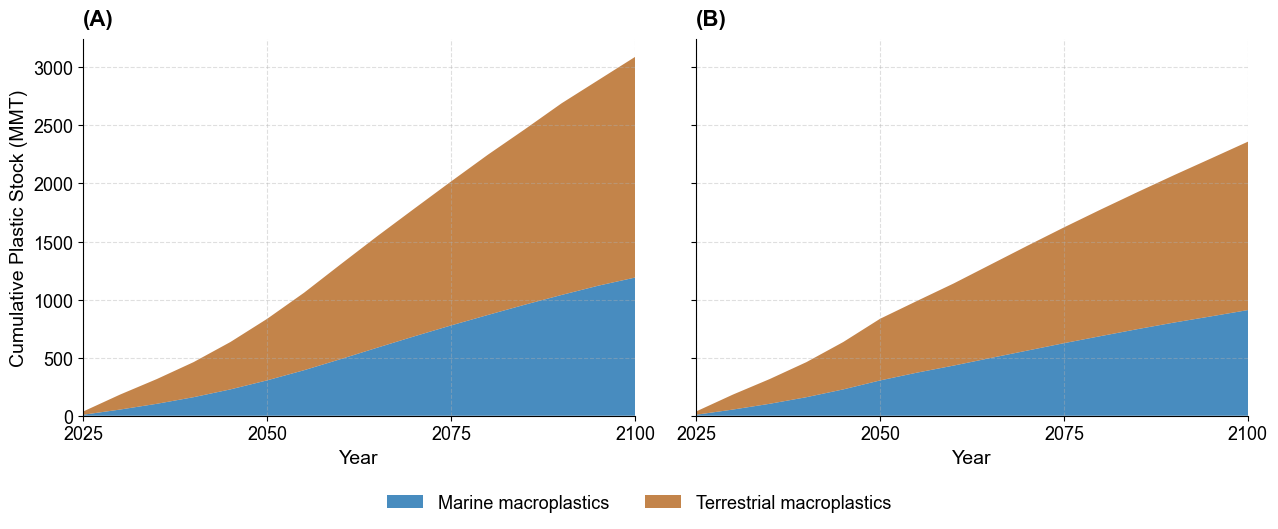

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Font settings ---
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14

# --- Load data ---
df_base = pd.read_csv("data/macro_accum_base.csv", index_col=0)
df_best = pd.read_csv("data/macro_accum_best.csv", index_col=0)

# --- Convert kg → MMT (1 MMT = 1e9 kg) ---
df_base = df_base / 1e9
df_best = df_best / 1e9

years = df_base.columns.astype(int)

# --- Colors ---
colors = {
    "Marine macroplastics":      "#1a6faf",
    "Terrestrial macroplastics": "#b5651d",
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

datasets = [
    (df_base, "(A)"),
    (df_best, "(B)"),
]

for ax, (df, title) in zip(axes, datasets):
    marine = df.loc["Marine macroplastics"].values.astype(float)
    terrestrial = df.loc["Terrestrial macroplastics"].values.astype(float)

    ax.stackplot(years,
                 marine, terrestrial,
                 labels=["Marine macroplastics", "Terrestrial macroplastics"],
                 colors=[colors["Marine macroplastics"], colors["Terrestrial macroplastics"]],
                 alpha=0.8)

    ax.set_title(title, fontsize=16, fontweight="bold", pad=10, loc="left")
    ax.set_xlabel("Year", fontsize=14)
    ax.set_xlim(years[0], years[-1])
    ax.set_xticks([2025, 2050, 2075, 2100])
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:.0f}")
    )

axes[0].set_ylabel("Cumulative Plastic Stock (MMT)", fontsize=14)

# Shared legend below both panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2,
           fontsize=13, frameon=False, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig("macro_accum_comparison.svg", dpi=150, bbox_inches="tight")
plt.savefig("macro_accum_comparison.pdf", dpi=150, bbox_inches="tight")
plt.show()

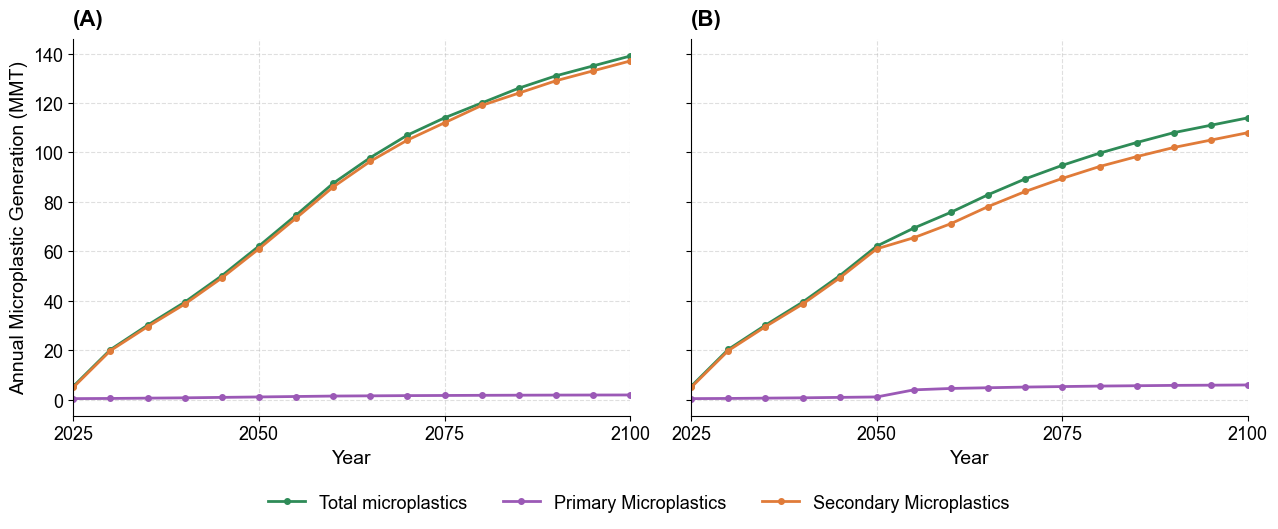

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Font settings ---
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14

# --- Load data ---
df_base = pd.read_csv("data/micro_base.csv", index_col=0)
df_best = pd.read_csv("data/micro_best.csv", index_col=0)

# --- Convert kg → MMT (1 MMT = 1e9 kg) ---
df_base = df_base / 1e9
df_best = df_best / 1e9

years = df_base.columns.astype(int)

# --- Colors ---
colors = {
    "Total microplastics":    "#2e8b57",
    "Primary Microplastics":  "#9b59b6",
    "Secondary Microplastics":"#e07b39",
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

datasets = [
    (df_base, "(A)"),
    (df_best, "(B)"),
]

for ax, (df, title) in zip(axes, datasets):
    for category, row in df.iterrows():
        values = row.values.astype(float)
        ax.plot(years, values, marker="o", markersize=4,
                linewidth=2, label=category, color=colors[category])

    ax.set_title(title, fontsize=16, fontweight="bold", pad=10, loc="left")
    ax.set_xlabel("Year", fontsize=14)
    ax.set_xlim(years[0], years[-1])
    ax.set_xticks([2025, 2050, 2075, 2100])
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:.0f}")
    )

axes[0].set_ylabel("Annual Microplastic Generation (MMT)", fontsize=14)

# Shared legend below both panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3,
           fontsize=13, frameon=False, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig("micro_generation_comparison.svg", dpi=150, bbox_inches="tight")
plt.savefig("micro_generation_comparison.pdf", dpi=150, bbox_inches="tight")

plt.show()

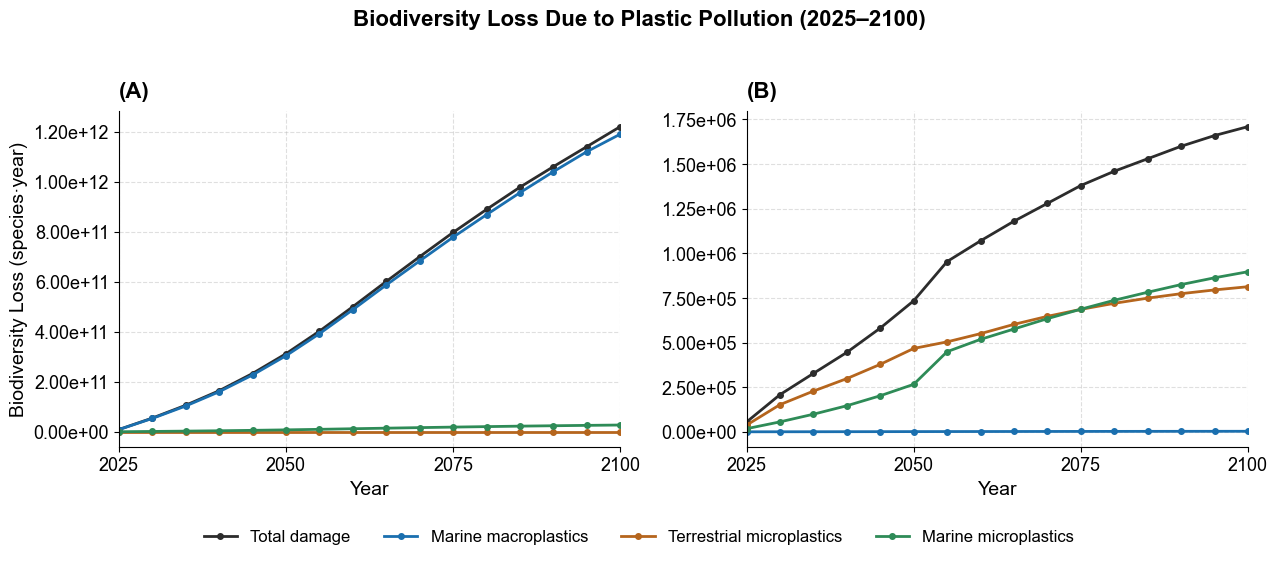

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Font settings ---
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14

# --- Load data ---
df_base = pd.read_csv("data/damage_base.csv", index_col=0)
df_best = pd.read_csv("data/damage_best.csv", index_col=0)

years = df_base.columns.astype(int)

# --- Colors ---
colors = {
    "Total damage":                        "#2c2c2c",
    "damage due to macroplastics marine":  "#1a6faf",
    "damage due to microplastics terrestrial": "#b5651d",
    "damage due to microplastics marine":  "#2e8b57",
}

# --- Labels for legend ---
labels_map = {
    "Total damage":                            "Total damage",
    "damage due to macroplastics marine":      "Marine macroplastics",
    "damage due to microplastics terrestrial": "Terrestrial microplastics",
    "damage due to microplastics marine":      "Marine microplastics",
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

datasets = [
    (df_base, "(A)"),
    (df_best, "(B)"),
]

for ax, (df, title) in zip(axes, datasets):
    for category, row in df.iterrows():
        values = row.values.astype(float)
        ax.plot(years, values, marker="o", markersize=4,
                linewidth=2, label=labels_map[category], color=colors[category])

    ax.set_title(title, fontsize=16, fontweight="bold", pad=10, loc="left")
    ax.set_xlabel("Year", fontsize=14)
    ax.set_xlim(years[0], years[-1])
    ax.set_xticks([2025, 2050, 2075, 2100])
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:.2e}")
    )

axes[0].set_ylabel("Biodiversity Loss (species·year)", fontsize=14)

# Shared legend below both panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4,
           fontsize=12, frameon=False, bbox_to_anchor=(0.5, -0.08))

fig.suptitle("Biodiversity Loss Due to Plastic Pollution (2025–2100)",
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("damage_comparison.svg", dpi=150, bbox_inches="tight")
plt.savefig("damage_comparison.pdf", dpi=150, bbox_inches="tight")

plt.show()